In [3]:
from torchvision import datasets

In [5]:
import os

data_path = '../chapter7/data/'
os.makedirs(data_path, exist_ok=True)

In [6]:
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

100.0%


In [7]:
len(cifar10)

50000

In [10]:
import matplotlib.pyplot as plt

In [14]:
image, label = cifar10[99]
print(image, label)

<PIL.Image.Image image mode=RGB size=32x32 at 0x11B195A00> 1


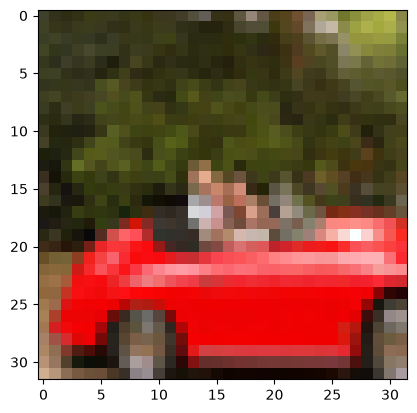

In [16]:
plt.imshow(image)
plt.show()

In [17]:
from torchvision import transforms

In [20]:
to_tensor = transforms.ToTensor()
img_t = to_tensor(image)

In [22]:
img_t.shape

torch.Size([3, 32, 32])

In [23]:
# pass transform directly to load data function

In [25]:
tensor_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.ToTensor()
)

In [ ]:
tensor_cifar10

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../chapter7/data/
    Split: Train
    StandardTransform
Transform: ToTensor()

In [27]:
image_t, _ = tensor_cifar10[99]
image_t.shape

torch.Size([3, 32, 32])

In [28]:
img_t.min()

tensor(0.)

In [29]:
img_t.max()

tensor(1.)

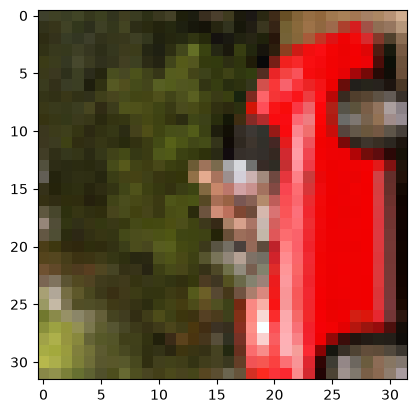

In [31]:
plt.imshow(img_t.permute(2,1,0))
plt.show()

In [35]:
import torch
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)

In [46]:
imgs.shape

torch.Size([3, 32, 32, 50000])

In [42]:
imgs.view(3,-1).shape

torch.Size([3, 51200000])

In [47]:
mean = imgs.view(3, -1).mean(dim=1)
mean

tensor([0.4914, 0.4822, 0.4465])

In [48]:
std = imgs.view(3,-1).std(dim=1)
std

tensor([0.2470, 0.2435, 0.2616])

In [52]:
transformed_cifar10 = datasets.CIFAR10(
    data_path,
    train=True,
    download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]
    )
)

In [55]:
tranformed_img, _ = transformed_cifar10[99]

In [56]:
tranformed_img.shape

torch.Size([3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9802374..2.1267896].


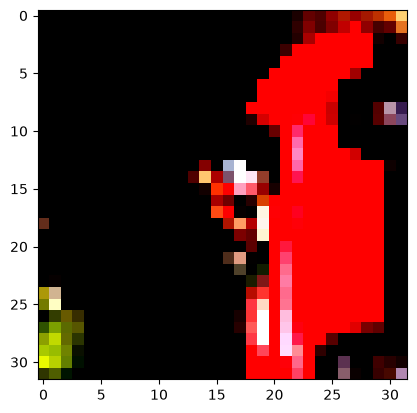

In [58]:
plt.imshow(tranformed_img.permute(2,1,0))
plt.show()

In [59]:
label_map = {0:0, 2:1}
cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0,2]]

In [ ]:
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0,2]]

In [103]:
to_tensor = transforms.ToTensor()
tensor_cifar2 = [(to_tensor(img), label) for img, label in cifar2]
tensor_cifar2_val = [(to_tensor(img), label) for img, label in cifar2_val]

In [62]:
import torch.nn as nn

In [63]:
n_out = 2

model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, n_out)
)

In [64]:
model

Sequential(
  (0): Linear(in_features=3072, out_features=512, bias=True)
  (1): Tanh()
  (2): Linear(in_features=512, out_features=2, bias=True)
)

In [65]:
softmax = nn.Softmax(dim=1)

In [66]:
x = torch.tensor([[1.0, 2.0, 3.0], [3.0, 2.0, 1.0]])

In [67]:
softmax(x)

tensor([[0.0900, 0.2447, 0.6652],
        [0.6652, 0.2447, 0.0900]])

In [68]:
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.Softmax(dim=1)
)

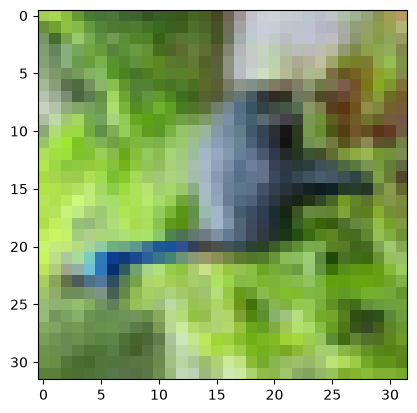

In [104]:
img, _ = tensor_cifar2[0]
plt.imshow(img.permute(2,1,0))
plt.show()

In [111]:
img_batch = tensor_cifar2[0][0]

img_batch = img_batch.view(-1).unsqueeze(0)

In [112]:
out = model(img_batch)

In [113]:
out

tensor([[0.4422, 0.5578]], grad_fn=<SoftmaxBackward0>)

In [116]:
_, index = torch.max(out, dim=1)
index

tensor([1])

In [117]:
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

In [121]:
img, label = tensor_cifar2[0]

In [122]:
out = model(img.view(-1).unsqueeze(0))

In [124]:
loss = nn.NLLLoss()

In [126]:
loss(out, torch.tensor([label]))

tensor(0.7010, grad_fn=<NllLossBackward0>)

In [131]:
import torch
import torch.nn as nn
import torch.optim as optim


model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 5

for epoch in range(n_epochs):
    for img, label in tensor_cifar2:
        img_tensor = img.view(-1).unsqueeze(0)
        label_tensor = torch.tensor([label])

        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

/var/folders/lb/pqbkjwts485cwcl0v7sfts_40000gn/T/ipykernel_38788/3671860366.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  print("Epoch: %d, Loss: %f" % (epoch, float(loss)))


Epoch: 0, Loss: 1.208132
Epoch: 1, Loss: 1.386501
Epoch: 2, Loss: 1.838939
Epoch: 3, Loss: 2.161985
Epoch: 4, Loss: 2.420211


In [136]:
train_loader = torch.utils.data.DataLoader(tensor_cifar2, batch_size=64, shuffle=True)

In [149]:
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 100


for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0]
        label_tensors = torch.tensor(labels)
        img_tensors = imgs.view(batch_size, -1)

        out = model(img_tensors)
        loss = loss_fn(out, label_tensors)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch: {epoch}, Loss: {float(loss)}')

/var/folders/lb/pqbkjwts485cwcl0v7sfts_40000gn/T/ipykernel_38788/2083666503.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensors = torch.tensor(labels)


Epoch: 0, Loss: 0.8637621402740479
Epoch: 1, Loss: 0.3799746334552765
Epoch: 2, Loss: 0.5130810141563416
Epoch: 3, Loss: 0.36239123344421387
Epoch: 4, Loss: 0.58204185962677
Epoch: 5, Loss: 0.5606673955917358
Epoch: 6, Loss: 0.5392159223556519
Epoch: 7, Loss: 0.4982646405696869
Epoch: 8, Loss: 0.267645001411438
Epoch: 9, Loss: 0.6137263178825378
Epoch: 10, Loss: 0.45460689067840576
Epoch: 11, Loss: 0.45957353711128235
Epoch: 12, Loss: 0.3020981252193451
Epoch: 13, Loss: 0.4704236388206482
Epoch: 14, Loss: 0.5295973420143127
Epoch: 15, Loss: 0.5469461679458618
Epoch: 16, Loss: 0.47234758734703064
Epoch: 17, Loss: 0.4668397009372711
Epoch: 18, Loss: 0.5088375806808472
Epoch: 19, Loss: 0.4400585889816284
Epoch: 20, Loss: 0.3509024679660797
Epoch: 21, Loss: 0.48310184478759766
Epoch: 22, Loss: 0.2685467600822449
Epoch: 23, Loss: 0.33734792470932007
Epoch: 24, Loss: 0.5724900364875793
Epoch: 25, Loss: 0.5027461051940918
Epoch: 26, Loss: 0.5186671614646912
Epoch: 27, Loss: 0.534968376159668


In [150]:
val_loader = torch.utils.data.DataLoader(tensor_cifar2_val, batch_size=64, shuffle=False)

In [152]:
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f", correct / total)

Accuracy: %f 0.8325


In [ ]:
model = nn.Sequential(
    nn.Linear(x, 1024),
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, 2),
)

In [154]:
loss_fn = nn.CrossEntropyLoss()

In [155]:
numel_list = [p.numel() for p in model.parameters()]

sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

# Review

In [1]:
from torchvision import datasets

In [2]:
import os

data_path = '../chapter7/data'

In [48]:
cifar10 = datasets.CIFAR10(data_path, train=True, download=False)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False)

In [7]:
len(cifar10)

50000

In [9]:
img, label = cifar10[99]

In [14]:
img, label

(<PIL.Image.Image image mode=RGB size=32x32>, 1)

# Apply transforms when loading the data

In [16]:
from torchvision import transforms

In [17]:
to_tensor = transforms.ToTensor()

img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [18]:
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=transforms.ToTensor())

In [20]:
img_t, _ = tensor_cifar10[99]

In [21]:
img_t.shape

torch.Size([3, 32, 32])

In [22]:
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

In [23]:
import matplotlib.pyplot as plt

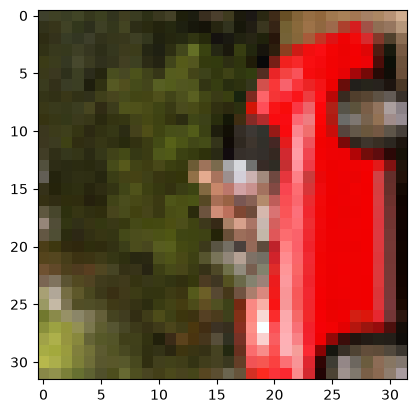

In [25]:
plt.imshow(img_t.permute(2,1,0))
plt.show()

In [26]:
import torch

In [27]:
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10],dim=3)

In [28]:
imgs.shape

torch.Size([3, 32, 32, 50000])

In [35]:
mean = imgs.view(3, -1).mean(dim=1)
std = imgs.view(3, -1).std(dim=1)

In [36]:
mean, std

(tensor([0.4914, 0.4822, 0.4465]), tensor([0.2470, 0.2435, 0.2616]))

In [38]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9802374..2.1267896].


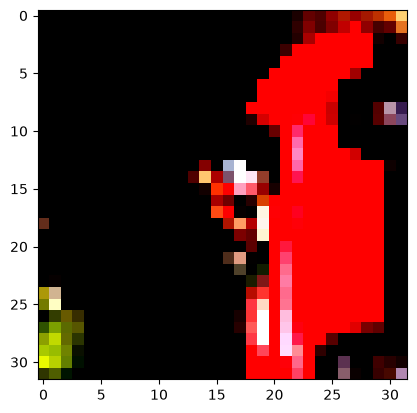

In [42]:
img_t, _ = transformed_cifar10[99]

plt.imshow(img_t.permute(2,1,0))
plt.show()

In [44]:
cifar10[0]

(<PIL.Image.Image image mode=RGB size=32x32>, 6)

In [49]:
label_map = {0: 0, 2:1}
class_names = ['airplane', 'bird']

cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]]

In [50]:
len(cifar2)

10000

In [51]:
len(cifar10_val)

10000

In [52]:
import torch.nn as nn

In [54]:
n_out = 2

model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, n_out),
    nn.Softmax(dim=1)
)

In [55]:
img, _ = cifar2[0]

In [58]:
from torchvision import transforms
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)

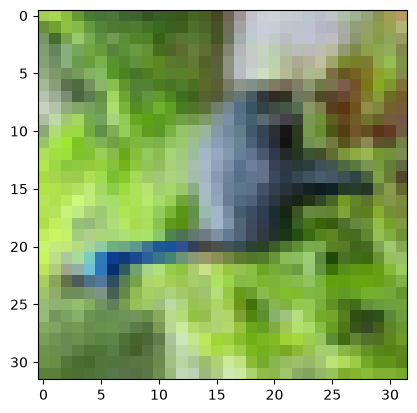

In [59]:
import matplotlib.pyplot as plot

plt.imshow(img_t.permute(2, 1, 0))
plt.show()

In [60]:
img_t.shape

torch.Size([3, 32, 32])

In [61]:
img_batch = img_t.view(-1).unsqueeze(dim=0)

In [64]:
out = model(img_batch)

In [65]:
out

tensor([[0.4531, 0.5469]], grad_fn=<SoftmaxBackward0>)

In [66]:
_, index = torch.max(out, dim=1)

In [67]:
index

tensor([1])

In [68]:
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

loss_fn = nn.NLLLoss()

In [76]:
img, label = cifar2[0]
img_t = to_tensor(img)

In [77]:
label

1

In [80]:
out = model(img_t.view(-1).unsqueeze(0))

In [81]:
loss_fn(out, torch.tensor([label]))

tensor(0.6187, grad_fn=<NllLossBackward0>)

# whole training loop

In [83]:
imgs.shape

torch.Size([3, 32, 32, 50000])

In [86]:
cifar2[0]

(<PIL.Image.Image image mode=RGB size=32x32>, 1)

In [88]:
import torch
import torch.optim as optim
from torchvision import transforms

to_tensor = transforms.ToTensor()

model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

loss_fn = nn.NLLLoss()

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
n_epoch = 5

for epoch in range(n_epoch):
    for img, label in cifar2:
        img_t = to_tensor(img)
        label_t = torch.tensor([label])

        out = model(img_t.view(-1).unsqueeze(0))
        optimizer.zero_grad()
        loss = loss_fn(out, label_t)
        loss.backward()
        optimizer.step()
    print(f'Epoch: {epoch}, loss: {loss}')

Epoch: 0, loss: 1.1648732423782349
Epoch: 1, loss: 1.35720694065094
Epoch: 2, loss: 1.9064446687698364
Epoch: 3, loss: 2.5578675270080566
Epoch: 4, loss: 2.703256368637085


In [106]:
cifar2_tensor = [(to_tensor(img), label) for img, label in cifar2]

In [107]:
train_loader = torch.utils.data.DataLoader(cifar2_tensor, batch_size=64, shuffle=True)

In [102]:
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim=1)
)

loss_fn = nn.NLLLoss()

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

n_epochs = 100

In [120]:
for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        
        batch_size = imgs.shape[0]
        label_t = torch.tensor(labels)

        out = model(imgs.view(batch_size, -1))
        loss = loss_fn(out, label_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

/var/folders/lb/pqbkjwts485cwcl0v7sfts_40000gn/T/ipykernel_90287/1853065511.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_t = torch.tensor(labels)


Epoch: 0, Loss: 0.400202
Epoch: 1, Loss: 0.709534
Epoch: 2, Loss: 0.310068
Epoch: 3, Loss: 0.524571
Epoch: 4, Loss: 0.233747
Epoch: 5, Loss: 0.270521
Epoch: 6, Loss: 0.140061
Epoch: 7, Loss: 0.311117
Epoch: 8, Loss: 0.379275
Epoch: 9, Loss: 0.462022
Epoch: 10, Loss: 0.152973
Epoch: 11, Loss: 0.627859
Epoch: 12, Loss: 0.367563
Epoch: 13, Loss: 0.260538
Epoch: 14, Loss: 0.226215
Epoch: 15, Loss: 0.504047
Epoch: 16, Loss: 0.121366
Epoch: 17, Loss: 0.274667
Epoch: 18, Loss: 0.254097
Epoch: 19, Loss: 0.109149
Epoch: 20, Loss: 0.377878
Epoch: 21, Loss: 0.362702
Epoch: 22, Loss: 0.412160
Epoch: 23, Loss: 0.441537
Epoch: 24, Loss: 0.557653
Epoch: 25, Loss: 0.287063
Epoch: 26, Loss: 0.207207
Epoch: 27, Loss: 0.345305
Epoch: 28, Loss: 0.267340
Epoch: 29, Loss: 0.084958
Epoch: 30, Loss: 0.153227
Epoch: 31, Loss: 0.303277
Epoch: 32, Loss: 0.214127
Epoch: 33, Loss: 0.288216
Epoch: 34, Loss: 0.223626
Epoch: 35, Loss: 0.201946
Epoch: 36, Loss: 0.375091
Epoch: 37, Loss: 0.264634
Epoch: 38, Loss: 0.217

In [121]:
cifar10_val_tensor = [(to_tensor(img), label) for img, label in cifar10_val]

In [122]:
val_loader = torch.utils.data.DataLoader(cifar10_val_tensor, batch_size=64, shuffle=False)

In [123]:
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))

        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print("Accuracy: %f", correct / total)

Accuracy: %f 0.1188
